# House Price Prediction — Exploratory Data Analysis

This notebook explores the USA Housing dataset to understand feature
distributions, correlations, and relationships with the target variable `Price`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

DATA_PATH = "../data/USA_Housing.csv"

## 1. Load and Inspect Data

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (5000, 7)

Data types:
 Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

First 5 rows:


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


In [3]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()

Missing values per column:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Duplicate rows: 0


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


## 2. Target Variable Analysis (`Price`)

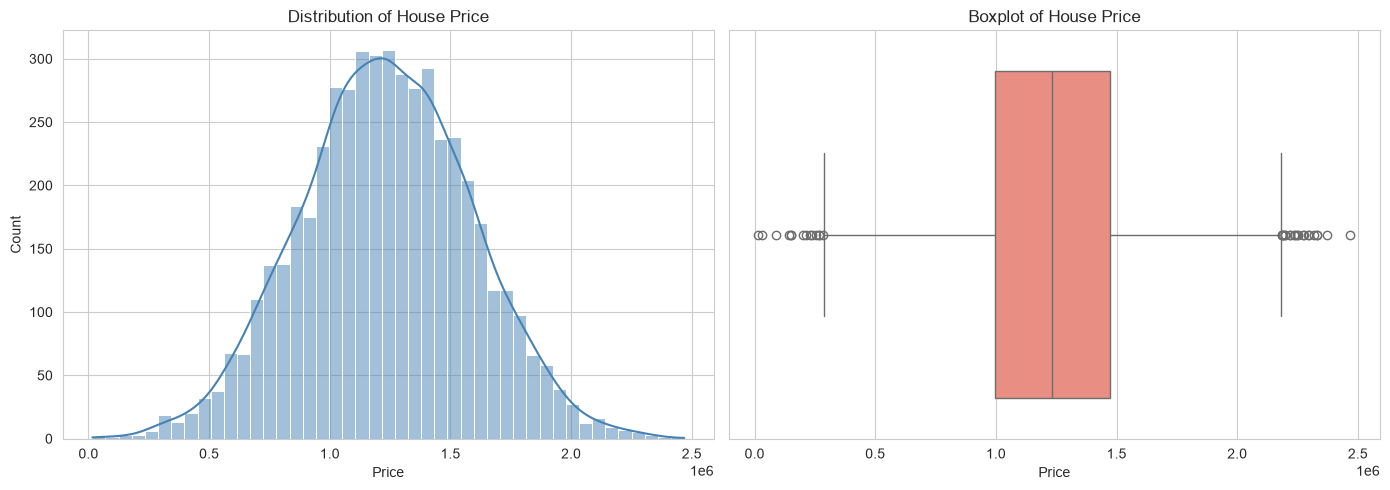

count    5.000000e+03
mean     1.232073e+06
std      3.531176e+05
min      1.593866e+04
25%      9.975771e+05
50%      1.232669e+06
75%      1.471210e+06
max      2.469066e+06
Name: Price, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Price")

sns.boxplot(x=df["Price"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot of House Price")

plt.tight_layout()
plt.show()

print(df["Price"].describe())

## 3. Feature Distributions

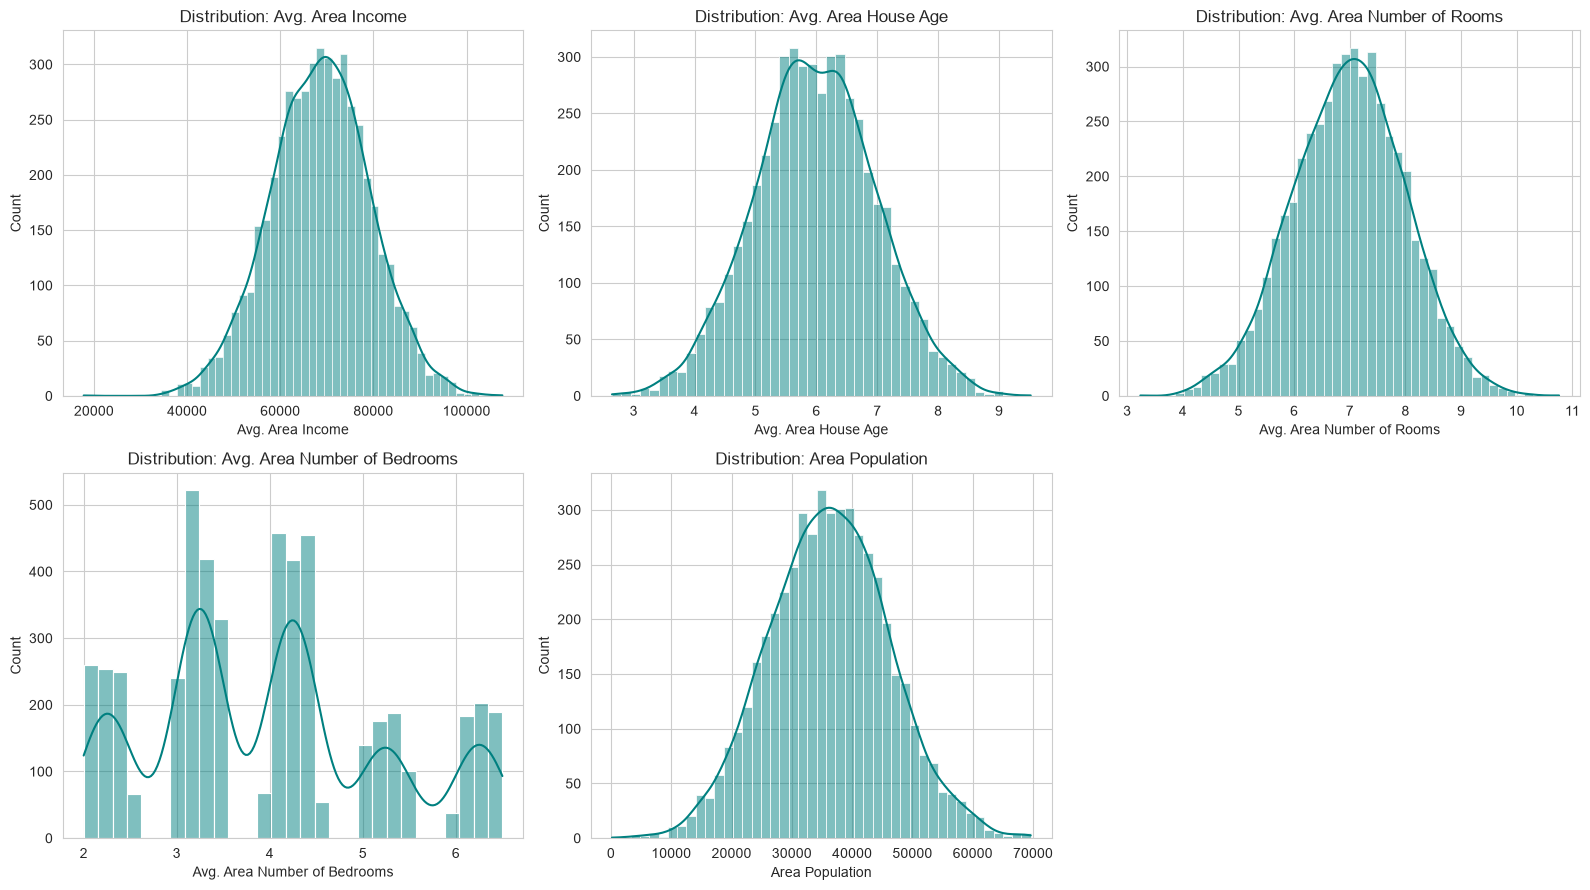

In [5]:
numeric_features = [
    "Avg. Area Income",
    "Avg. Area House Age",
    "Avg. Area Number of Rooms",
    "Avg. Area Number of Bedrooms",
    "Area Population",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color="teal")
    axes[i].set_title(f"Distribution: {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 4. Correlation Analysis

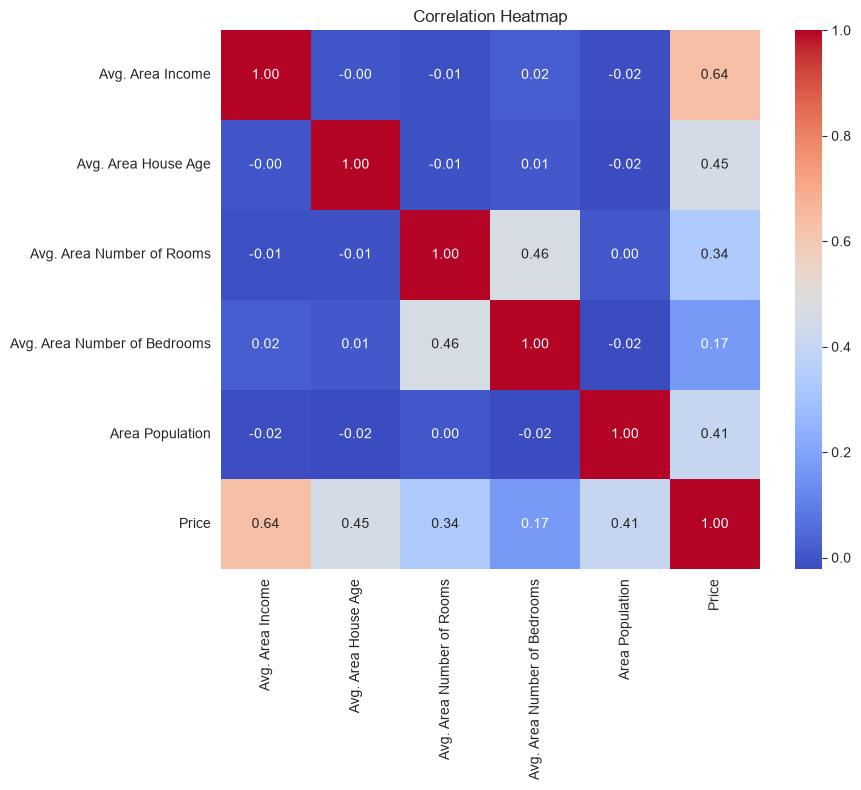

Correlation with Price (sorted):
Price                           1.000000
Avg. Area Income                0.639734
Avg. Area House Age             0.452543
Area Population                 0.408556
Avg. Area Number of Rooms       0.335664
Avg. Area Number of Bedrooms    0.171071
Name: Price, dtype: float64


In [6]:
corr_matrix = df[numeric_features + ["Price"]].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with Price (sorted):")
print(corr_matrix["Price"].sort_values(ascending=False))

## 5. Scatter Plots — Price vs Each Feature

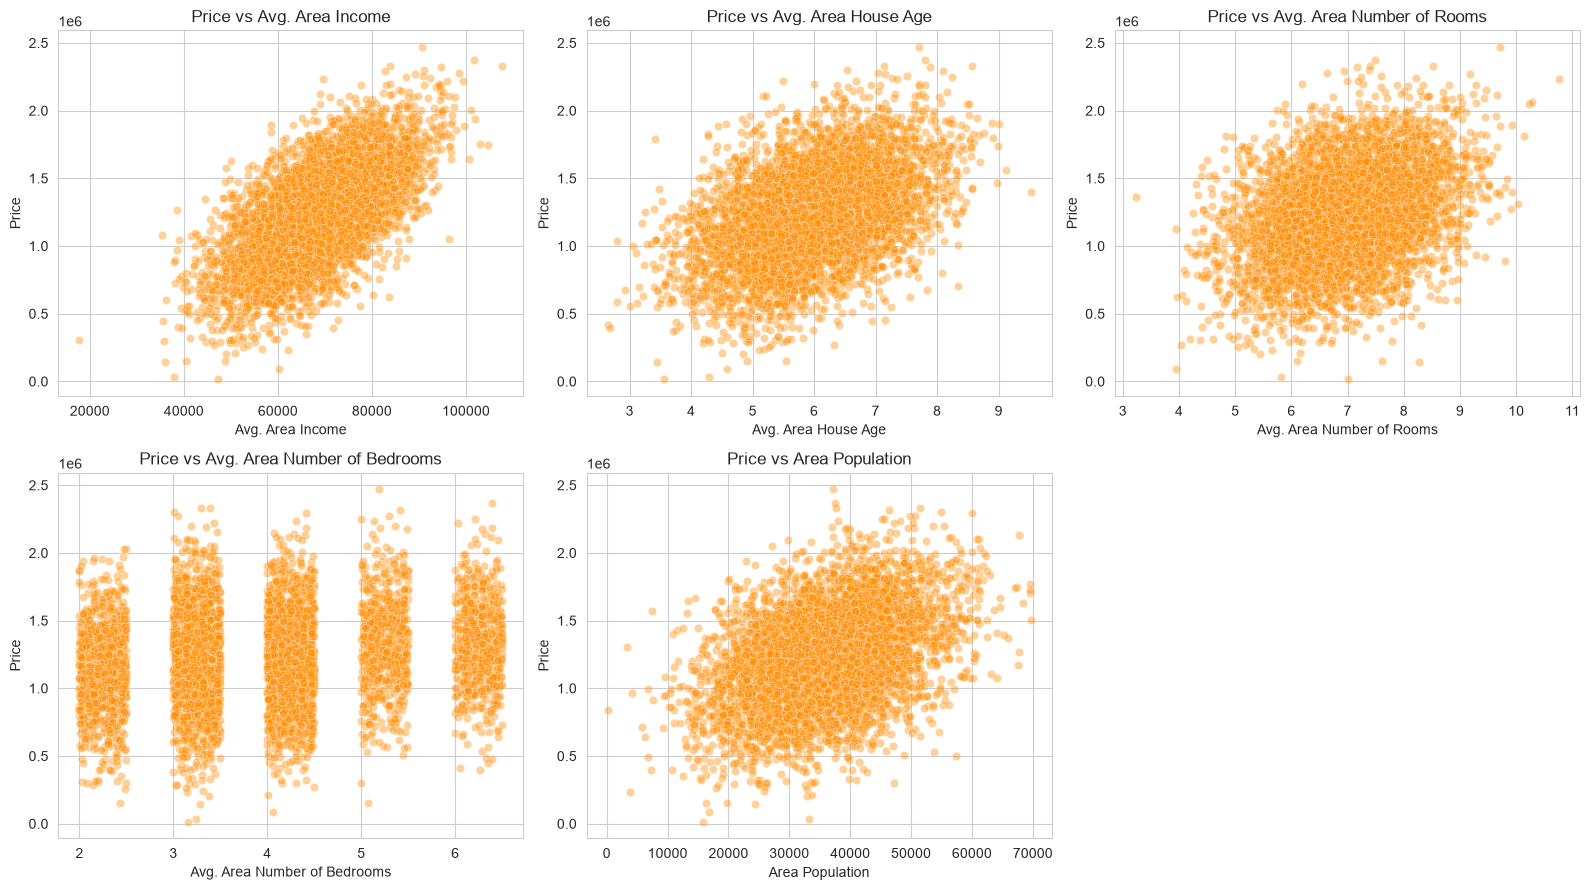

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.scatterplot(x=df[col], y=df["Price"], ax=axes[i], alpha=0.4, color="darkorange")
    axes[i].set_title(f"Price vs {col}")

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## 6. Key Findings

- **Avg. Area Income** shows the strongest positive correlation with `Price`.
- All numeric features show roughly **linear** relationships with `Price` — no strong
  non-linear curvature is visible in the scatter plots.
- No missing values or duplicate rows were found in the dataset.
- **Address** is a free-text/high-cardinality field and adds no predictive value for a
  simple regression model, so it will be **excluded** from modeling.
- Features selected for modeling: `Avg. Area Income`, `Avg. Area House Age`,
  `Avg. Area Number of Rooms`, `Avg. Area Number of Bedrooms`, `Area Population`.
- Given the mostly linear relationships, **Linear Regression, Ridge, Lasso, and
  Polynomial+Ridge** are expected to perform well; KNN may struggle to generalize
  with sparse high-dimensional distances.